##Titanic Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)
df=pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##Basic Info


In [6]:
print("Shape: ",df.shape)
df.info()

Shape:  (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


##Missing Values


In [7]:
missing=df.isnull().sum()
missing_pct=(missing/len(df)*100).round(2)
missing_df=pd.DataFrame({"missing_count": missing,"missing_pct":missing_pct})
missing_df=missing_df[missing_df.missing_count>0].sort_values("missing_count",ascending=False)
missing_df




,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


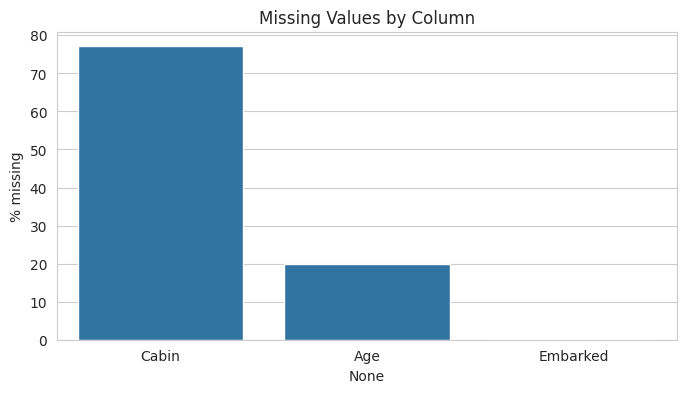

In [8]:
plt.figure(figsize=(8,4))
sns.barplot(x=missing_df.index, y=missing_df["missing_pct"])
plt.ylabel("% missing")
plt.title("Missing Values by Column")
plt.show()

##Variable target Survived

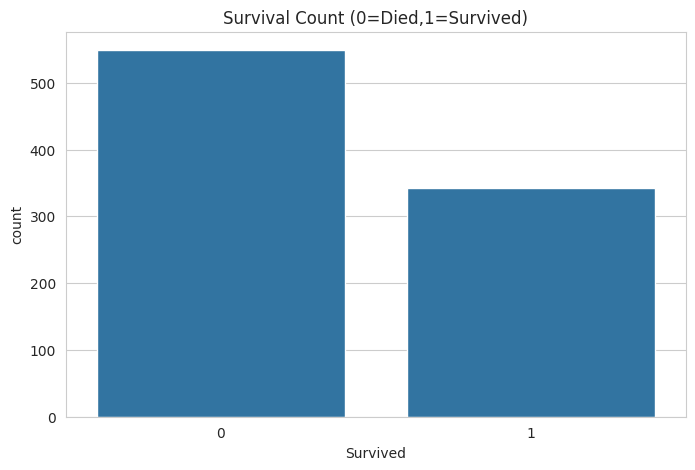

In [9]:
df["Survived"].value_counts(normalize=True).round(3)*100
sns.countplot(data=df,x="Survived")
plt.title("Survival Count (0=Died,1=Survived)")
plt.show()


##Univariate Analysis

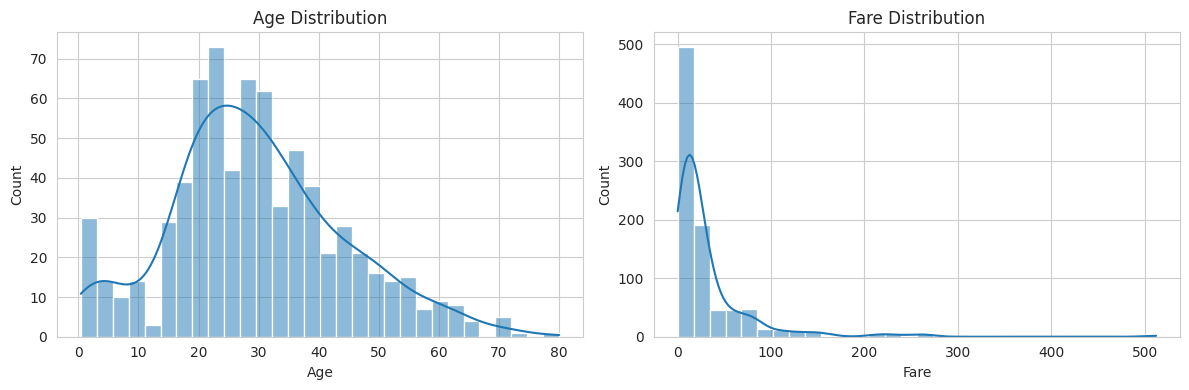

In [10]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
sns.histplot(df["Age"].dropna(),bins=30,kde=True,ax=axes[0])
axes[0].set_title("Age Distribution")
sns.histplot(df["Fare"],bins=30,kde=True,ax=axes[1])
axes[1].set_title("Fare Distribution")
plt.tight_layout()
plt.show()

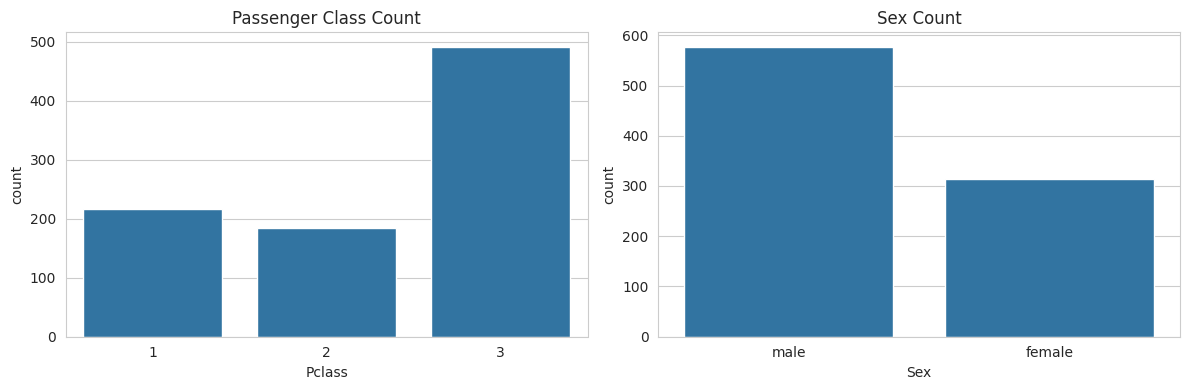

In [11]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
sns.countplot(data=df,x="Pclass",ax=axes[0])
axes[0].set_title("Passenger Class Count")
sns.countplot(data=df,x="Sex",ax=axes[1])
axes[1].set_title("Sex Count")
plt.tight_layout()
plt.show()

##Bivariate Analysis


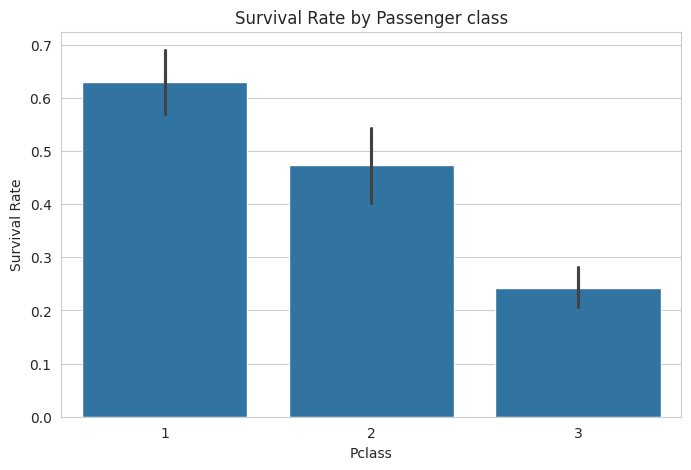

In [12]:
sns.barplot(data=df,x="Pclass",y="Survived")
plt.title("Survival Rate by Passenger class")
plt.ylabel("Survival Rate")
plt.show()


##Survival rate by Sex

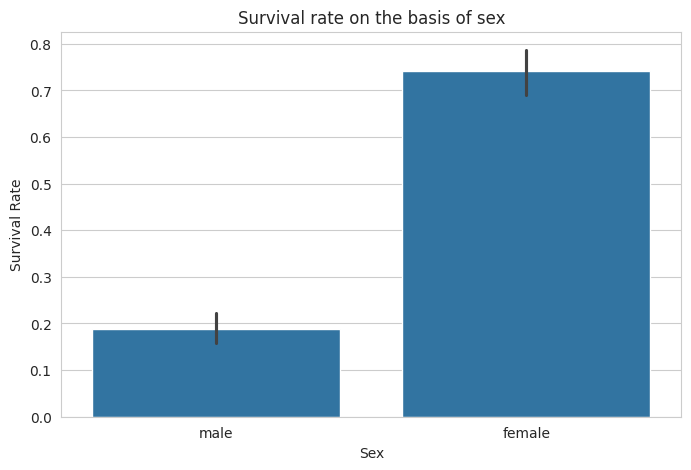

In [13]:
sns.barplot(data=df,x="Sex",y="Survived")
plt.title("Survival rate on the basis of sex")
plt.ylabel("Survival Rate")
plt.show()

##Age distribution by Survival


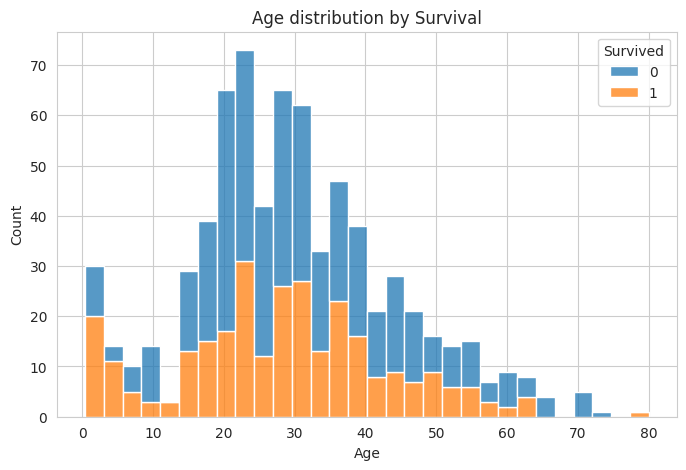

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Age",hue="Survived",multiple="stack",bins=30)
plt.title("Age distribution by Survival")
plt.show()


##Correlation Heatmap


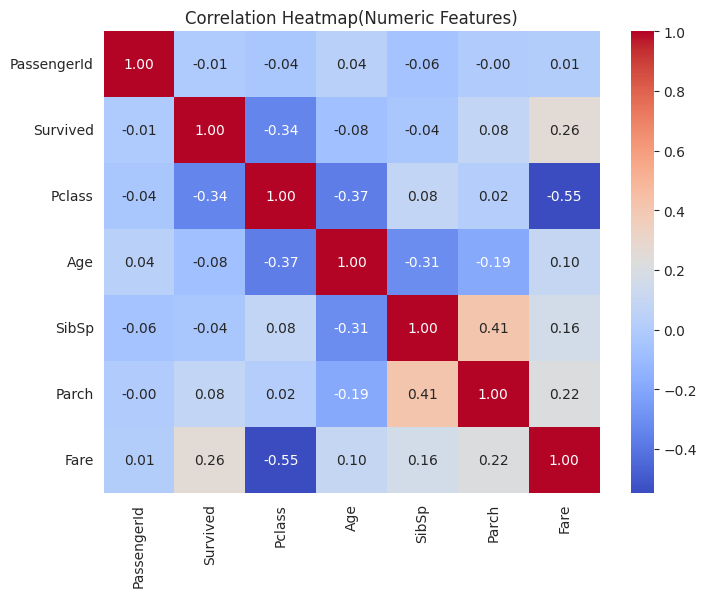

In [15]:
numeric_df=df.select_dtypes(include=[np.number])
corr=numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap(Numeric Features)")
plt.show()

##Data Cleaning

In [16]:
df_clean=df.copy()
df_clean.shape
#Missing Ages
median_age=df_clean["Age"].median()
df_clean["Age"]=df_clean["Age"].fillna(median_age)
print("Filled missing values with median:",median_age)
print("Remaining missing values: ",df_clean["Age"].isnull().sum())

Filled missing values with median: 28.0
Remaining missing values:  0


In [17]:
#Handling missing Embarked
mode_embarked=df_clean["Embarked"].mode()[0]
df_clean["Embarked"]=df_clean["Embarked"].fillna(mode_embarked)
print("Filled missing Embarked with mode:",mode_embarked)
print("Remaining missing embarked values: ",df_clean["Embarked"].isnull().sum)

Filled missing Embarked with mode: S
Remaining missing embarked values:  <bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Embarked, Length: 891, dtype: bool>


In [18]:
#Handling Cabin
df_clean["Has_Cabin"]=df_clean["Cabin"].notnull().astype(int)
df_clean=df_clean.drop(columns=["Cabin"])
df_clean["Has_Cabin"].value_counts()

,count
Has_Cabin,
0,687
1,204


In [19]:
#Cleaning Title Column
df_clean["Title"]=df_clean["Name"].str.extract(r",\s*([^\.]*)\.")
df_clean["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
df_clean = df_clean.drop(columns=["PassengerId", "Ticket", "Name"])
df_clean.head()

In [25]:
#Fixing Datatypes
cat_cols=["Survived","Pclass","Sex","Embarked","Title","Has_Cabin"]
df_clean[cat_cols]=df_clean[cat_cols].astype("category")
df_clean.dtypes

,0
Survived,category
Pclass,category
Sex,category
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,category
Has_Cabin,category
Title,category


In [26]:
#Final Checking
print("Missing values left:\n",df_clean.isnull().sum())
print("\nShape after cleaning: ",df_clean.shape)
df_clean.head()

Missing values left:
 Survived     0
Pclass       0
Sex          0
Age          0
SibSp        0
Parch        0
Fare         0
Embarked     0
Has_Cabin    0
Title        0
dtype: int64

Shape after cleaning:  (891, 10)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,Title
0,0,3,male,22.0,1,0,7.2500,S,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs
2,1,3,female,26.0,0,0,7.9250,S,0,Miss
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs
4,0,3,male,35.0,0,0,8.0500,S,0,Mr


In [27]:
df_clean.to_csv("train_cleaned.csv",index=False)
print("Saved train_cleaned.csv")

Saved train_cleaned.csv
